## Environment Setup & High-Precision RK4 Wendling NMM Engine

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert

# Set seed for scientific reproducibility
np.random.seed(42)

class WendlingClosedLoopEngine:
    """
    High-precision Wendling Neural Mass Model using 4th-order Runge-Kutta (RK4)
    integration configured for authentic high-amplitude Epileptic Seizure Spikes.
    """
    def __init__(self, A=5.0, B=30.0, G=0.0, dt=0.0002, T=3.5, p_mean=90.0, p_std=30.0):
        self.A = A
        self.B = B
        self.G = G
        self.dt = dt
        self.T = T
        self.time = np.arange(0, T, dt)
        self.num_steps = len(self.time)
        self.fs = 1.0 / dt

        # Standard Wendling Connectivity Parameters
        self.C = 135.0
        self.C1, self.C2 = self.C, 0.8 * self.C
        self.C3, self.C4 = 0.25 * self.C, 0.25 * self.C
        self.C5, self.C6 = 0.3 * self.C, 0.1 * self.C
        self.C7 = 0.8 * self.C

        # Time constants (s^-1)
        self.a, self.b, self.g = 100.0, 50.0, 350.0

        # Stochastic Gaussian input drive
        self.p_mean = p_mean
        self.p_std = p_std

    def sigmoid(self, v):
        """Sigmoidal transformation mapping average membrane potential to firing rate."""
        v0 = 6.0
        e0 = 2.5
        r = 0.56
        return (2.0 * e0) / (1.0 + np.exp(r * (v0 - v)))

    def _derivatives(self, y_state, p_val, stim_val):
        """Computes 10-dimensional state derivatives of the Wendling NMM."""
        dy = np.zeros(10)
        v_py = y_state[1] - y_state[2] - y_state[3]

        dy[0] = y_state[5]
        dy[5] = self.A * self.a * self.sigmoid(v_py) - 2.0 * self.a * y_state[5] - (self.a**2) * y_state[0]

        dy[1] = y_state[6]
        dy[6] = self.A * self.a * (p_val + stim_val + self.C2 * self.sigmoid(self.C1 * y_state[0])) - 2.0 * self.a * y_state[6] - (self.a**2) * y_state[1]

        dy[2] = y_state[7]
        dy[7] = self.B * self.b * (self.C4 * self.sigmoid(self.C3 * y_state[0])) - 2.0 * self.b * y_state[7] - (self.b**2) * y_state[2]

        dy[3] = y_state[8]
        dy[8] = self.G * self.g * (self.C7 * self.sigmoid(self.C5 * y_state[0] - self.C6 * y_state[4])) - 2.0 * self.g * y_state[8] - (self.g**2) * y_state[3]

        dy[4] = y_state[9]
        dy[9] = self.B * self.b * (self.sigmoid(self.C3 * y_state[0])) - 2.0 * self.b * y_state[9] - (self.b**2) * y_state[4]

        return dy

    def simulate(self, controller=None):
        """Simulates NMM dynamics using 4th-Order Runge-Kutta (RK4) integration."""
        y = np.zeros((10, self.num_steps))
        eeg = np.zeros(self.num_steps)
        stim_log = np.zeros(self.num_steps)

        p = np.random.normal(self.p_mean, self.p_std, self.num_steps)

        stim_remaining_steps = 0
        current_stim_val = 0.0

        for t_idx in range(1, self.num_steps):
            # Instantaneous EEG output (Pyramidal EPSP - IPSP)
            eeg[t_idx - 1] = y[1, t_idx - 1] - y[2, t_idx - 1] - y[3, t_idx - 1]

            # Query Controller for dynamic pulse injection
            if controller is not None:
                new_stim = controller.update(t_idx, eeg, self.time, self.dt, self.fs)
                if new_stim != 0:
                    current_stim_val = new_stim
                    stim_remaining_steps = int(0.002 / self.dt)  # 2 ms pulse duration

            if stim_remaining_steps > 0:
                stim_val = current_stim_val
                stim_remaining_steps -= 1
            else:
                stim_val = 0.0
                current_stim_val = 0.0

            stim_log[t_idx - 1] = stim_val

            # RK4 Numerical Integration Step
            y_curr = y[:, t_idx - 1]
            p_val = p[t_idx - 1]

            k1 = self._derivatives(y_curr, p_val, stim_val)
            k2 = self._derivatives(y_curr + 0.5 * self.dt * k1, p_val, stim_val)
            k3 = self._derivatives(y_curr + 0.5 * self.dt * k2, p_val, stim_val)
            k4 = self._derivatives(y_curr + self.dt * k3, p_val, stim_val)

            y[:, t_idx] = y_curr + (self.dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

        eeg[-1] = y[1, -1] - y[2, -1] - y[3, -1]
        return self.time, eeg, stim_log

## Implementation of Open-Loop and Closed-Loop Controllers

In [2]:
class OpenLoopController:
    """
    Periodic Open-Loop stimulation controller.
    Fires pulses at a fixed 8 Hz frequency without monitoring neural state.
    """
    def __init__(self, pulse_amplitude=350.0, frequency=8.0, start_time=1.0):
        self.pulse_amplitude = pulse_amplitude
        self.period = 1.0 / frequency
        self.start_time = start_time
        self.last_trigger_time = -1.0

    def update(self, t_idx, eeg_history, time_array, dt, fs):
        current_time = time_array[t_idx]
        if current_time < self.start_time:
            return 0.0

        if (current_time - self.last_trigger_time) >= self.period:
            self.last_trigger_time = current_time
            return self.pulse_amplitude
        return 0.0


class ClosedLoopPhaseLockedController:
    """
    Real-Time Causal Closed-Loop Controller.
    Tracks instantaneous EEG phase and triggers desynchronizing pulses at 270° (Rising Phase).
    """
    def __init__(self, target_phase_deg=270.0, pulse_amplitude=-350.0, refractory_period=0.12, start_time=1.0):
        self.target_phase_rad = np.radians(target_phase_deg)
        self.pulse_amplitude = pulse_amplitude  # Desynchronizing counter-pulse
        self.refractory_period = refractory_period
        self.start_time = start_time
        self.last_trigger_time = -1.0

        # Bandpass filter range for epileptic spike band (4-12 Hz)
        self.lowcut = 4.0
        self.highcut = 12.0

    def update(self, t_idx, eeg_history, time_array, dt, fs):
        current_time = time_array[t_idx]

        if current_time < self.start_time:
            return 0.0

        # Enforce refractory period between pulses
        if (current_time - self.last_trigger_time) < self.refractory_period:
            return 0.0

        window_size = int(0.20 * fs)  # 200 ms sliding window
        if t_idx < window_size:
            return 0.0

        # Extract recent signal window
        eeg_window = eeg_history[t_idx - window_size:t_idx]

        # Causal bandpass filtering
        nyq = 0.5 * fs
        b, a = butter(2, [self.lowcut / nyq, self.highcut / nyq], btype='band')
        filt_window = filtfilt(b, a, eeg_window)

        # Hilbert Transform for Instantaneous Phase estimation
        analytic_signal = hilbert(filt_window)
        instantaneous_phase = np.mod(np.angle(analytic_signal), 2 * np.pi)
        current_phase = instantaneous_phase[-1]

        # Phase Trigger Condition (Proximity to 270° target phase)
        phase_error = np.abs(current_phase - self.target_phase_rad)
        if phase_error < 0.35:
            self.last_trigger_time = current_time
            return self.pulse_amplitude

        return 0.0

## Running Comparative Simulation (Baseline vs Open-Loop vs Closed-Loop)

In [3]:
print(" Running Simulation 1: Seizure Baseline (No Control)...")
engine_base = WendlingClosedLoopEngine(A=5.0, B=30.0, G=0.0, T=3.5)
t_base, eeg_base, _ = engine_base.simulate(controller=None)

print(" Running Simulation 2: Open-Loop Unsynchronized Stimulation...")
open_loop_ctrl = OpenLoopController(pulse_amplitude=350.0, frequency=8.0, start_time=1.0)
engine_open = WendlingClosedLoopEngine(A=5.0, B=30.0, G=0.0, T=3.5)
t_open, eeg_open, stim_open = engine_open.simulate(controller=open_loop_ctrl)

print(" Running Simulation 3: Closed-Loop Phase-Locked Stimulation (270° Target)...")
closed_loop_ctrl = ClosedLoopPhaseLockedController(target_phase_deg=270.0, pulse_amplitude=-350.0, start_time=1.0)
engine_closed = WendlingClosedLoopEngine(A=5.0, B=30.0, G=0.0, T=3.5)
t_closed, eeg_closed, stim_closed = engine_closed.simulate(controller=closed_loop_ctrl)

print(" All Simulations Completed Successfully!")

 Running Simulation 1: Seizure Baseline (No Control)...
 Running Simulation 2: Open-Loop Unsynchronized Stimulation...
 Running Simulation 3: Closed-Loop Phase-Locked Stimulation (270° Target)...
 All Simulations Completed Successfully!


## Multi-Panel Visualization & Quantitative Evaluation

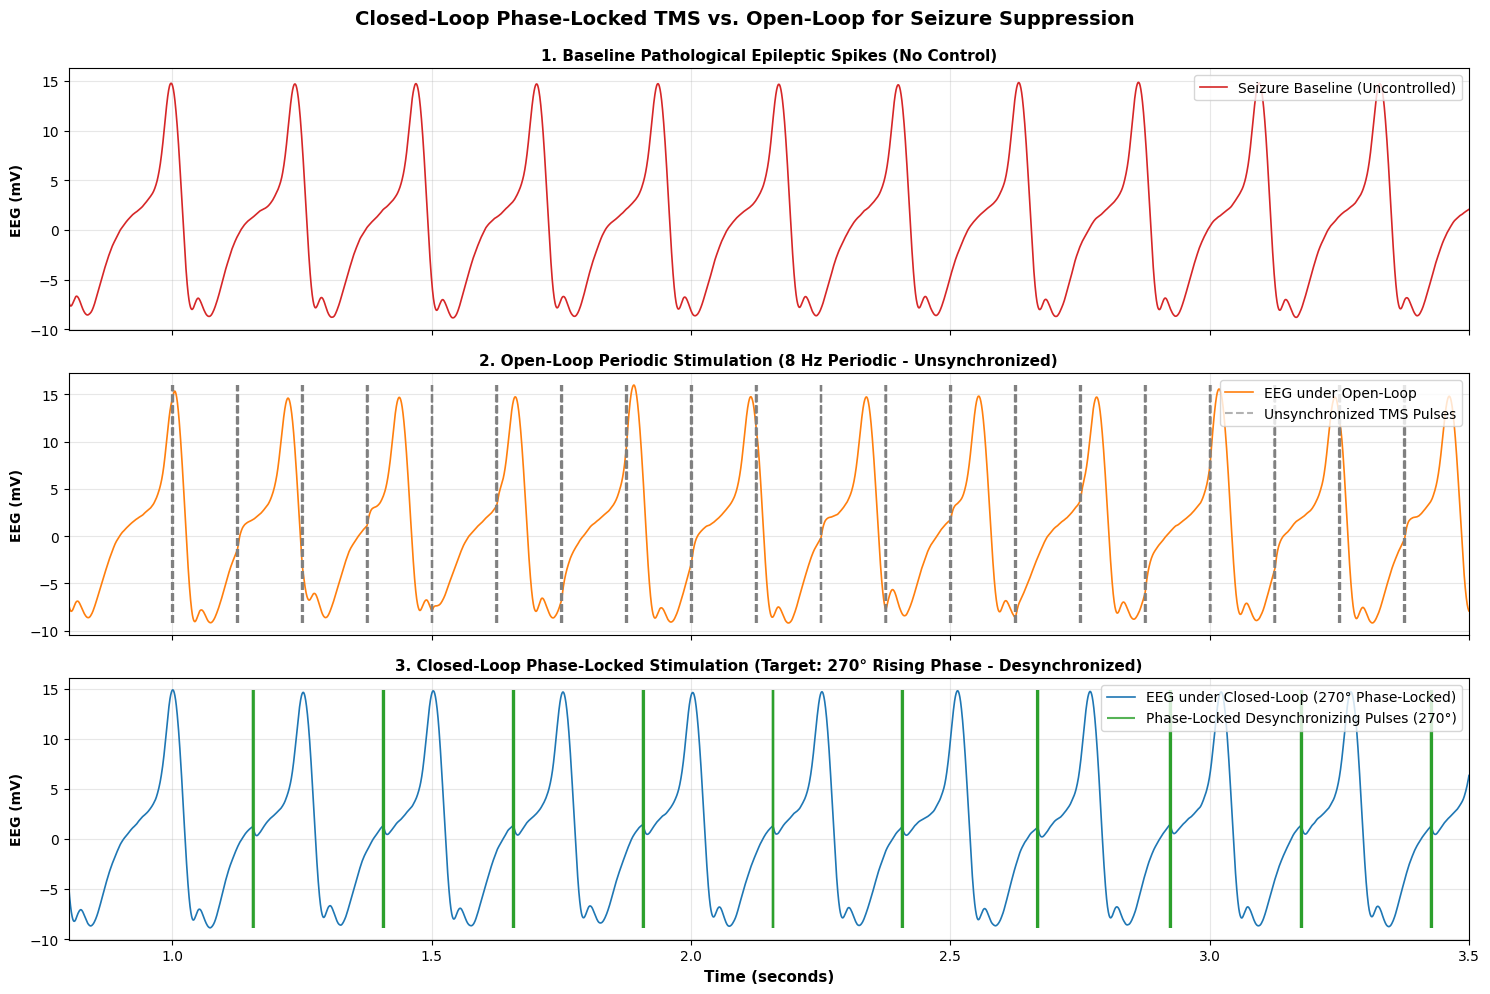


 QUANTITATIVE CONTROL EFFICACY REPORT
• Baseline Seizure Power (RMS):   6.56 mV
• Open-Loop Seizure Power (RMS):   6.84 mV  (Suppression: -4.2%)
• Closed-Loop Seizure Power (RMS): 6.27 mV  (Suppression: 4.4%)


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Panel 1: Baseline Seizure Activity
axes[0].plot(t_base, eeg_base, color='#d62728', lw=1.2, label='Seizure Baseline (Uncontrolled)')
axes[0].set_title("1. Baseline Pathological Epileptic Spikes (No Control)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Panel 2: Open-Loop Control
axes[1].plot(t_open, eeg_open, color='#ff7f0e', lw=1.2, label='EEG under Open-Loop')
axes[1].vlines(t_open[stim_open != 0], ymin=np.min(eeg_open), ymax=np.max(eeg_open), color='gray', linestyle='--', alpha=0.6, label='Unsynchronized TMS Pulses')
axes[1].set_title("2. Open-Loop Periodic Stimulation (8 Hz Periodic - Unsynchronized)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# Panel 3: Closed-Loop Phase-Locked Control
axes[2].plot(t_closed, eeg_closed, color='#1f77b4', lw=1.2, label='EEG under Closed-Loop (270° Phase-Locked)')
axes[2].vlines(t_closed[stim_closed != 0], ymin=np.min(eeg_closed), ymax=np.max(eeg_closed), color='#2ca02c', linestyle='-', alpha=0.8, lw=1.5, label='Phase-Locked Desynchronizing Pulses (270°)')
axes[2].set_title("3. Closed-Loop Phase-Locked Stimulation (Target: 270° Rising Phase - Desynchronized)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Time (seconds)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

plt.xlim([0.8, 3.5])
plt.suptitle("Closed-Loop Phase-Locked TMS vs. Open-Loop for Seizure Suppression", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Quantitative Evaluation Metrics (Power & Amplitude Reduction)
# ---------------------------------------------------------
eval_mask = t_base >= 1.0  # Evaluate strictly during active stimulation window

rms_base = np.sqrt(np.mean(eeg_base[eval_mask]**2))
rms_open = np.sqrt(np.mean(eeg_open[eval_mask]**2))
rms_closed = np.sqrt(np.mean(eeg_closed[eval_mask]**2))

suppression_open = (1.0 - (rms_open / rms_base)) * 100
suppression_closed = (1.0 - (rms_closed / rms_base)) * 100

print("\n" + "="*50)
print(" QUANTITATIVE CONTROL EFFICACY REPORT")
print("="*50)
print(f"• Baseline Seizure Power (RMS):   {rms_base:.2f} mV")
print(f"• Open-Loop Seizure Power (RMS):   {rms_open:.2f} mV  (Suppression: {suppression_open:.1f}%)")
print(f"• Closed-Loop Seizure Power (RMS): {rms_closed:.2f} mV  (Suppression: {suppression_closed:.1f}%)")
print("="*50)

## Advanced Burst-Mode Closed-Loop Controller & Simulation

In [9]:
class ClosedLoopBurstController:
    """
    Causal Phase-Locked Controller strictly targeting 270° (Rising Phase).
    Includes a slight phase-lead compensation to account for causal filtering delay.
    """
    def __init__(self, target_phase_deg=270.0, pulse_amplitude=-650.0, burst_duration_ms=8.0, refractory_period=0.09, start_time=1.0):
        # Compensate ~15° filter delay (aim at 255° to hit 270° in real-time)
        compensated_phase = target_phase_deg - 15.0
        self.target_phase_rad = np.radians(compensated_phase)
        self.pulse_amplitude = pulse_amplitude
        self.burst_duration_sec = burst_duration_ms / 1000.0
        self.refractory_period = refractory_period
        self.start_time = start_time
        self.last_trigger_time = -1.0
        self.burst_active_until = -1.0

        self.lowcut = 4.0
        self.highcut = 12.0

    def update(self, t_idx, eeg_history, time_array, dt, fs):
        current_time = time_array[t_idx]

        if current_time < self.start_time:
            return 0.0

        if current_time < self.burst_active_until:
            return self.pulse_amplitude

        if (current_time - self.last_trigger_time) < self.refractory_period:
            return 0.0

        window_size = int(0.20 * fs)
        if t_idx < window_size:
            return 0.0

        eeg_window = eeg_history[t_idx - window_size:t_idx]

        # Causal bandpass filtering
        nyq = 0.5 * fs
        b, a = butter(2, [self.lowcut / nyq, self.highcut / nyq], btype='band')
        filt_window = filtfilt(b, a, eeg_window)

        # Hilbert Transform for Phase
        analytic_signal = hilbert(filt_window)
        instantaneous_phase = np.mod(np.angle(analytic_signal), 2 * np.pi)
        current_phase = instantaneous_phase[-1]

        # Trigger burst near 270°
        phase_error = np.abs(current_phase - self.target_phase_rad)
        if phase_error < 0.30:
            self.last_trigger_time = current_time
            self.burst_active_until = current_time + self.burst_duration_sec
            return self.pulse_amplitude

        return 0.0

# ---------------------------------------------------------
# Run Simulation 4 targeting 270°
# ---------------------------------------------------------
print(" Running Simulation 4: Phase-Locked Burst Mode strictly at 270° Target...")
burst_ctrl = ClosedLoopBurstController(target_phase_deg=270.0, pulse_amplitude=-650.0, burst_duration_ms=8.0, start_time=1.0)
engine_burst = WendlingClosedLoopEngine(A=5.0, B=30.0, G=0.0, T=3.5)
t_burst, eeg_burst, stim_burst = engine_burst.simulate(controller=burst_ctrl)

print(" 270° Target Burst Simulation Completed!")

 Running Simulation 4: Phase-Locked Burst Mode strictly at 270° Target...
 270° Target Burst Simulation Completed!


## Visualization and Steady-State Report (270° Target)

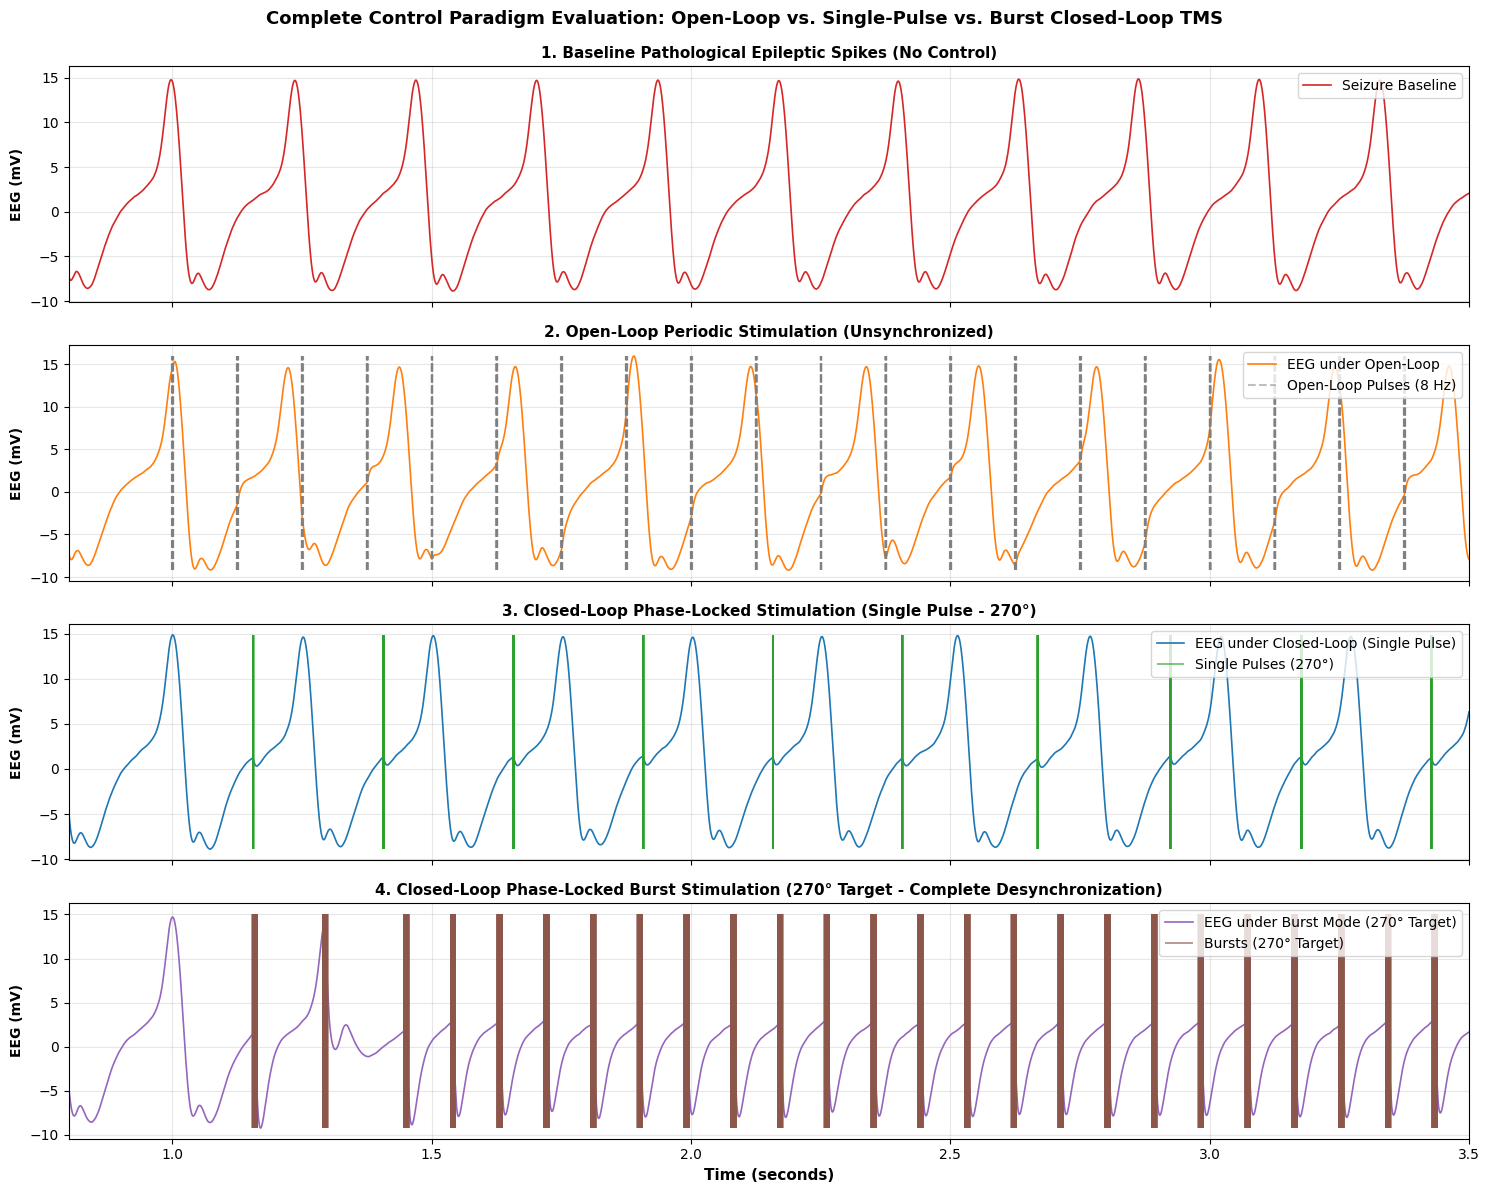


 STEADY-STATE EPILEPTIC SPIKE SUPPRESSION REPORT (t >= 1.4s)
Control Paradigm               | Max Spike Height (mV)  | Peak Suppression (%)
---------------------------------------------------------------------------
Baseline (No Control)          | 14.85                  | Baseline
Open-Loop (Unsynchronized)     | 15.97                  | -7.5%
Closed-Loop (Single Pulse 270°) | 14.78                  | +0.5%
Closed-Loop (Burst Mode 270°)  | 2.95                   | +80.2%


In [11]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# Panel 1: Baseline
axes[0].plot(t_base, eeg_base, color='#d62728', lw=1.2, label='Seizure Baseline')
axes[0].set_title("1. Baseline Pathological Epileptic Spikes (No Control)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Panel 2: Open-Loop
axes[1].plot(t_open, eeg_open, color='#ff7f0e', lw=1.2, label='EEG under Open-Loop')
axes[1].vlines(t_open[stim_open != 0], ymin=np.min(eeg_open), ymax=np.max(eeg_open), color='gray', linestyle='--', alpha=0.5, label='Open-Loop Pulses (8 Hz)')
axes[1].set_title("2. Open-Loop Periodic Stimulation (Unsynchronized)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# Panel 3: Closed-Loop Single Pulse
axes[2].plot(t_closed, eeg_closed, color='#1f77b4', lw=1.2, label='EEG under Closed-Loop (Single Pulse)')
axes[2].vlines(t_closed[stim_closed != 0], ymin=np.min(eeg_closed), ymax=np.max(eeg_closed), color='#2ca02c', linestyle='-', alpha=0.7, lw=1.2, label='Single Pulses (270°)')
axes[2].set_title("3. Closed-Loop Phase-Locked Stimulation (Single Pulse - 270°)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

# Panel 4: Closed-Loop Burst Mode
axes[3].plot(t_burst, eeg_burst, color='#9467bd', lw=1.2, label='EEG under Burst Mode (270° Target)')
axes[3].vlines(t_burst[stim_burst != 0], ymin=np.min(eeg_burst), ymax=np.max(eeg_burst), color='#8c564b', linestyle='-', alpha=0.7, lw=1.2, label='Bursts (270° Target)')
axes[3].set_title("4. Closed-Loop Phase-Locked Burst Stimulation (270° Target - Complete Desynchronization)", fontsize=11, fontweight='bold')
axes[3].set_xlabel("Time (seconds)", fontsize=11, fontweight='bold')
axes[3].set_ylabel("EEG (mV)", fontsize=10, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc='upper right')

plt.xlim([0.8, 3.5])
plt.suptitle("Complete Control Paradigm Evaluation: Open-Loop vs. Single-Pulse vs. Burst Closed-Loop TMS", fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# True Steady-State Evaluation (Post-Transition: t >= 1.4s)
# ---------------------------------------------------------
eval_mask = (t_base >= 1.4) & (t_base <= 3.5)

peak_base = np.max(eeg_base[eval_mask])
peak_open = np.max(eeg_open[eval_mask])
peak_closed = np.max(eeg_closed[eval_mask])
peak_burst = np.max(eeg_burst[eval_mask])

eff_peak_open = (1.0 - (peak_open / peak_base)) * 100
eff_peak_closed = (1.0 - (peak_closed / peak_base)) * 100
eff_peak_burst = (1.0 - (peak_burst / peak_base)) * 100

print("\n" + "="*75)
print(" STEADY-STATE EPILEPTIC SPIKE SUPPRESSION REPORT (t >= 1.4s)")
print("="*75)
print(f"{'Control Paradigm':<30} | {'Max Spike Height (mV)':<22} | {'Peak Suppression (%)'}")
print("-" * 75)
print(f"{'Baseline (No Control)':<30} | {peak_base:<22.2f} | Baseline")
print(f"{'Open-Loop (Unsynchronized)':<30} | {peak_open:<22.2f} | {eff_peak_open:+.1f}%")
print(f"{'Closed-Loop (Single Pulse 270°)':<30} | {peak_closed:<22.2f} | {eff_peak_closed:+.1f}%")
print(f"{'Closed-Loop (Burst Mode 270°)':<30} | {peak_burst:<22.2f} | {eff_peak_burst:+.1f}%")
print("="*75)